# Supplemental Figure 1: Compared Validated Data

This notebook compares low-throughput validation data to high-throughput experimental and predicted measurements for affinity, polyspecificity, and expression.


In [1]:
from pathlib import Path
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import odr
from scipy.stats import pearsonr, spearmanr, linregress
from matplotlib.gridspec import GridSpec
plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})
# Output directories (original S_FIG folder system)
S_FIG_1B = 'S_Figure_1b'
S_FIG_1C = 'S_Figure_1c'
S_FIG_1D = 'S_Figure_1d'
for subdir in [S_FIG_1B, S_FIG_1C, S_FIG_1D]:
    Path(subdir).mkdir(parents=True, exist_ok=True)

os.makedirs('analysis', exist_ok=True)


## Data Loading

Load affinity, expression, and polyspecificity datasets (experimental, predicted, low-throughput validation), then load polyspecificity and expression inputs used in downstream comparisons.


In [2]:
# load high-throughput experimental affinity data
wuhan_e = pd.read_csv('../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/wuhan_affinity_cleaned.csv')
wuhan_e['geno'] = wuhan_e['geno'].astype('str').str.zfill(13)
wuhan_e.rename(columns={'wuhan_log10Kd_mean':'w_kd_mean_e','wuhan_log10Kd_sem':'w_kd_sem_e'}, inplace=True)
wuhan_e = wuhan_e[['geno','w_kd_mean_e','w_kd_sem_e']]

ba1_e = pd.read_csv('../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/ba1_affinity_cleaned.csv')
ba1_e['geno'] = ba1_e['geno'].astype('str').str.zfill(13)
ba1_e.rename(columns={'ba1_log10Kd_mean':'ba1_kd_mean_e','ba1_log10Kd_sem':'ba1_kd_sem_e'}, inplace=True)
ba1_e = ba1_e[['geno','ba1_kd_mean_e','ba1_kd_sem_e']] 

ba4_e = pd.read_csv('../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/ba4_affinity_cleaned.csv')
ba4_e['geno'] = ba4_e['geno'].astype('str').str.zfill(13)
ba4_e.rename(columns={'ba4_log10Kd_mean':'ba4_kd_mean_e','ba4_log10Kd_sem':'ba4_kd_sem_e'}, inplace=True)
ba4_e = ba4_e[['geno','ba4_kd_mean_e','ba4_kd_sem_e']]

ht_exp = wuhan_e.merge(ba1_e, on='geno',how='outer').merge(ba4_e, on='geno',how='outer')


In [3]:
# load predicted affinity datasets from linear interaction models
wuhan_p = pd.read_csv('../../epistasis_inference/linear_interaction_models/wuhan/reference-based/predicted_phenotypes/wuhan_raw_2order_full_biochem_predictions.csv')
wuhan_p['geno'] = wuhan_p['geno'].astype('str').str.zfill(13)
wuhan_p.rename(columns={'predicted_phenotype':'w_kd_mean_p','prediction_se':'w_kd_sem_p'}, inplace=True)

ba1_p = pd.read_csv('../../epistasis_inference/linear_interaction_models/ba1/reference-based/predicted_phenotypes/ba1_raw_3order_full_biochem_predictions.csv')
ba1_p['geno'] = ba1_p['geno'].astype('str').str.zfill(13)
ba1_p.rename(columns={'predicted_phenotype':'ba1_kd_mean_p','prediction_se':'ba1_kd_sem_p'}, inplace=True)

ba4_p = pd.read_csv('../../epistasis_inference/linear_interaction_models/ba4/reference-based/predicted_phenotypes/ba4_raw_3order_full_biochem_predictions.csv')
ba4_p['geno'] = ba4_p['geno'].astype('str').str.zfill(13)
ba4_p.rename(columns={'predicted_phenotype':'ba4_kd_mean_p','prediction_se':'ba4_kd_sem_p'}, inplace=True)

ht_pred = wuhan_p.merge(ba1_p, on='geno').merge(ba4_p, on='geno')


In [4]:
# load low-throughput experimental affinity data
lt_val = pd.read_csv('../../BioPhy-Seq_measurements/isogenic_low-throughput_measurements/affinity/Omi32_low-throughput_affinities.csv')
lt_val['geno'] = lt_val['geno'].astype('str').str.zfill(13)

merged = lt_val.merge(ht_exp, on='geno',how='left').merge(ht_pred, on='geno',how='left')
merged.to_csv('analysis/lt_ht_exp_pred_combined.csv')

In [5]:
# switch antibody names to match psr low-throughput dataset
geno_ab = lt_val[['geno','antibody']].copy()
geno_ab.loc[geno_ab['antibody']=='omi', 'antibody'] = 'OMI32'
geno_ab.loc[geno_ab['antibody']=='gl', 'antibody'] = 'GERMLINE'

# load low-throughput experimental polyspecificity data
psr_lt = pd.read_csv('../../BioPhy-Seq_measurements/isogenic_low-throughput_measurements/polyspecificity_and_expression/analysis/polyspecificity_EC50_summary.csv')
psr_lt.rename(columns={'shortname':'antibody'}, inplace=True)
psr_lt = psr_lt.merge(geno_ab, on='antibody',how='left')
psr_lt['mean_log_EC50_lt'] = -psr_lt['mean_log_EC50']
psr_lt = psr_lt[['geno','mean_log_EC50_lt','sem_log_EC50']]
expr_lt = pd.read_csv('../../BioPhy-Seq_measurements/isogenic_low-throughput_measurements/polyspecificity_and_expression/analysis/omi_lt_expression-analysis.csv')

# load high-throughput experimental polyspecificity data
psr_expr = pd.read_csv('../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/polyspecificity/psr_cleaned.csv')
psr_expr['geno'] = psr_expr['geno'].astype('str').str.zfill(13)
psr_expr = psr_expr[['geno','mean_EC50_3p','SEM_EC50_3p']]

# load predicted polyspecificity data from linear interaction models
psr_pred = pd.read_csv('../../epistasis_inference/linear_interaction_models/psr/reference-based/predicted_phenotypes/psr_raw_2order_full_biochem_predictions.csv')
psr_pred['geno'] = psr_pred['geno'].astype('str').str.zfill(13)
psr_pred.rename(columns={'predicted_phenotype':'mean_EC50_3p_pred','prediction_se':'SEM_EC50_3p_pred'}, inplace=True)
psr_pred = psr_pred[['geno','mean_EC50_3p_pred','SEM_EC50_3p_pred']]

# merge datasets 
merged_psr = psr_lt.merge(psr_expr, on='geno',how='left').merge(psr_pred, on='geno',how='left')

# calculate average and sem of high-throughput psr EC50 for antibody variants that didn't pass the quality threshold for the cleaned dataset but were used for the low-throughput measurements
## these variants just barely missed the quality threshold for the cleaned dataset, so we still include them for the validation analysis
psr_raw_1 = pd.read_csv('../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/raw_outputs/20251022_psr_rep1-2_FINAL/psr_ec50s/Kds_Omi32g.tsv', sep='\t')
psr_raw_1['geno'] = psr_raw_1['geno'].astype('str').str.zfill(13)
psr_raw_2 = pd.read_csv('../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/raw_outputs/20251022_psr_rep1-2_FINAL/psr_ec50s/Kds_Omi32h.tsv', sep='\t')
psr_raw_2['geno'] = psr_raw_2['geno'].astype('str').str.zfill(13)
geno_list = ['1010100010100', '1111111111111']
var_1_mean = (psr_raw_1[psr_raw_1['geno'] == geno_list[0]]['PSR_log10EC50'].values[0] + psr_raw_2[psr_raw_2['geno'] == geno_list[0]]['PSR_log10EC50'].values[0])/2
var_1_sem = np.abs(psr_raw_1[psr_raw_1['geno'] == geno_list[0]]['PSR_log10EC50'].values[0] - psr_raw_2[psr_raw_2['geno'] == geno_list[0]]['PSR_log10EC50'].values[0])/2
var_2_mean = (psr_raw_1[psr_raw_1['geno'] == geno_list[1]]['PSR_log10EC50'].values[0] + psr_raw_2[psr_raw_2['geno'] == geno_list[1]]['PSR_log10EC50'].values[0])/2
var_2_sem = np.abs(psr_raw_1[psr_raw_1['geno'] == geno_list[1]]['PSR_log10EC50'].values[0] - psr_raw_2[psr_raw_2['geno'] == geno_list[1]]['PSR_log10EC50'].values[0])/2
merged_psr.loc[merged_psr['geno']=='1010100010100', 'mean_EC50_3p'] = var_1_mean
merged_psr.loc[merged_psr['geno']=='1010100010100', 'SEM_EC50_3p'] = var_1_sem
merged_psr.loc[merged_psr['geno']=='1111111111111', 'mean_EC50_3p'] = var_2_mean
merged_psr.loc[merged_psr['geno']=='1111111111111', 'SEM_EC50_3p'] = var_2_sem

In [6]:
# load high-throughput expression data
expr_expr = pd.read_csv('../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/expression/filtered_expression_replicates.csv')
expr_expr['geno'] = expr_expr['geno'].astype('str').str.zfill(13)
expr_expr.rename(columns={'expr_mednorm_mean':'mean_expr_e','expr_mednorm_sem':'sem_expr_e'}, inplace=True)
expr_expr = expr_expr[['geno','mean_expr_e','sem_expr_e']]

# load predicted expression data from linear interaction models
expr_pred = pd.read_csv('../../epistasis_inference/linear_interaction_models/expression/reference-based/predicted_phenotypes/expression_raw_2order_full_biochem_predictions.csv')
expr_pred['geno'] = expr_pred['geno'].astype('str').str.zfill(13)
expr_pred.rename(columns={'predicted_phenotype':'mean_expr_p','prediction_se':'sem_expr_p'}, inplace=True)
expr_pred = expr_pred[['geno','mean_expr_p','sem_expr_p']]

# Keep full tables for global Exp-vs-Pred analyses
expr_expr_full = expr_expr.copy()
expr_pred_full = expr_pred.copy()


**Delta expression calculation for high-throughput and predicted datasets**

In [7]:
# Calculate delta expression for high-throughput data
print("Calculating delta expression for experimental high-throughput data...")

expr_expr = expr_expr.merge(geno_ab, on='geno', how='right')
expr_pred = expr_pred.merge(geno_ab, on='geno', how='right')

antibodies_expr = expr_expr['antibody'].unique()

for ref_antibody in antibodies_expr:
    ref_rows = expr_expr[expr_expr['antibody'] == ref_antibody]

    ref_expr = ref_rows['mean_expr_e'].values
    ref_sem  = ref_rows['sem_expr_e'].values  # <-- propagate

    if len(ref_expr) > 0:
        ref_expr = ref_expr[0]
        ref_sem  = ref_sem[0] if len(ref_sem) > 0 and pd.notna(ref_sem[0]) else np.nan

        delta_col     = f'delta_ab_{ref_antibody}_expr'
        delta_sem_col = f'sem_delta_ab_{ref_antibody}_expr'  # <-- NEW

        expr_expr[delta_col] = expr_expr['mean_expr_e'] - ref_expr

        # error propagation: sqrt(sem_i^2 + sem_ref^2)
        expr_expr[delta_sem_col] = np.sqrt(
            np.square(expr_expr['sem_expr_e'].astype(float)) +
            (ref_sem ** 2 if np.isfinite(ref_sem) else np.nan)
        )

print(f"Added {len(antibodies_expr)} delta columns (+ SEM) to experimental data")
print(expr_expr.head())


Calculating delta expression for experimental high-throughput data...
Added 10 delta columns (+ SEM) to experimental data
            geno  mean_expr_e  sem_expr_e antibody  delta_ab_2205_expr  \
0  0100010100110     4.170471    0.060109     2205            0.000000   
1  1100100011001     4.478918    0.042304     6396            0.308447   
2  1010001000100     4.239494    0.101506     5173            0.069023   
3  1100100111110     4.327557    0.087920     6432            0.157086   
4  1001000100011     4.351449    0.080027     4628            0.180978   

   sem_delta_ab_2205_expr  delta_ab_6396_expr  sem_delta_ab_6396_expr  \
0                0.085006           -0.308447                0.073503   
1                0.073503            0.000000                0.059827   
2                0.117969           -0.239423                0.109969   
3                0.106504           -0.151360                0.097568   
4                0.100087           -0.127468                0.09052

In [8]:
# Calculate delta expression for predicted data from linear interaction models
print("\nCalculating delta expression for predicted high-throughput data...")

antibodies_pred = expr_pred['antibody'].unique()

for ref_antibody in antibodies_pred:
    ref_rows = expr_pred[expr_pred['antibody'] == ref_antibody]

    ref_expr = ref_rows['mean_expr_p'].values
    ref_sem  = ref_rows['sem_expr_p'].values  # <-- propagate

    if len(ref_expr) > 0:
        ref_expr = ref_expr[0]
        ref_sem  = ref_sem[0] if len(ref_sem) > 0 and pd.notna(ref_sem[0]) else np.nan

        delta_col     = f'delta_ab_{ref_antibody}_pred'
        delta_sem_col = f'sem_delta_ab_{ref_antibody}_pred'  # <-- NEW

        expr_pred[delta_col] = expr_pred['mean_expr_p'] - ref_expr

        expr_pred[delta_sem_col] = np.sqrt(
            np.square(expr_pred['sem_expr_p'].astype(float)) +
            (ref_sem ** 2 if np.isfinite(ref_sem) else np.nan)
        )

print(f"Added {len(antibodies_pred)} delta columns (+ SEM) to predicted data")
print(expr_pred.head())



Calculating delta expression for predicted high-throughput data...
Added 10 delta columns (+ SEM) to predicted data
            geno  mean_expr_p  sem_expr_p antibody  delta_ab_2205_pred  \
0  0100010100110     4.330529    0.014084     2205            0.000000   
1  1100100011001     4.369273    0.014126     6396            0.038744   
2  1010001000100     4.146902    0.014092     5173           -0.183626   
3  1100100111110     4.366455    0.014148     6432            0.035926   
4  1001000100011     4.300748    0.014094     4628           -0.029781   

   sem_delta_ab_2205_pred  delta_ab_6396_pred  sem_delta_ab_6396_pred  \
0                0.019917           -0.038744                0.019947   
1                0.019947            0.000000                0.019977   
2                0.019923           -0.222370                0.019953   
3                0.019963           -0.002818                0.019993   
4                0.019925           -0.068525                0.019954   


In [9]:
# Save the delta expression datasets
expr_expr.to_csv('analysis/ht_expression_with_deltas.csv', index=False)
expr_pred.to_csv('analysis/pred_expression_with_deltas.csv', index=False)

print("\nSaved datasets with delta expression:")
print("  - experimental_datasets/expression_with_deltas.csv")
print("  - expression_with_deltas.csv")



Saved datasets with delta expression:
  - experimental_datasets/expression_with_deltas.csv
  - expression_with_deltas.csv


## Affinity Comparisons


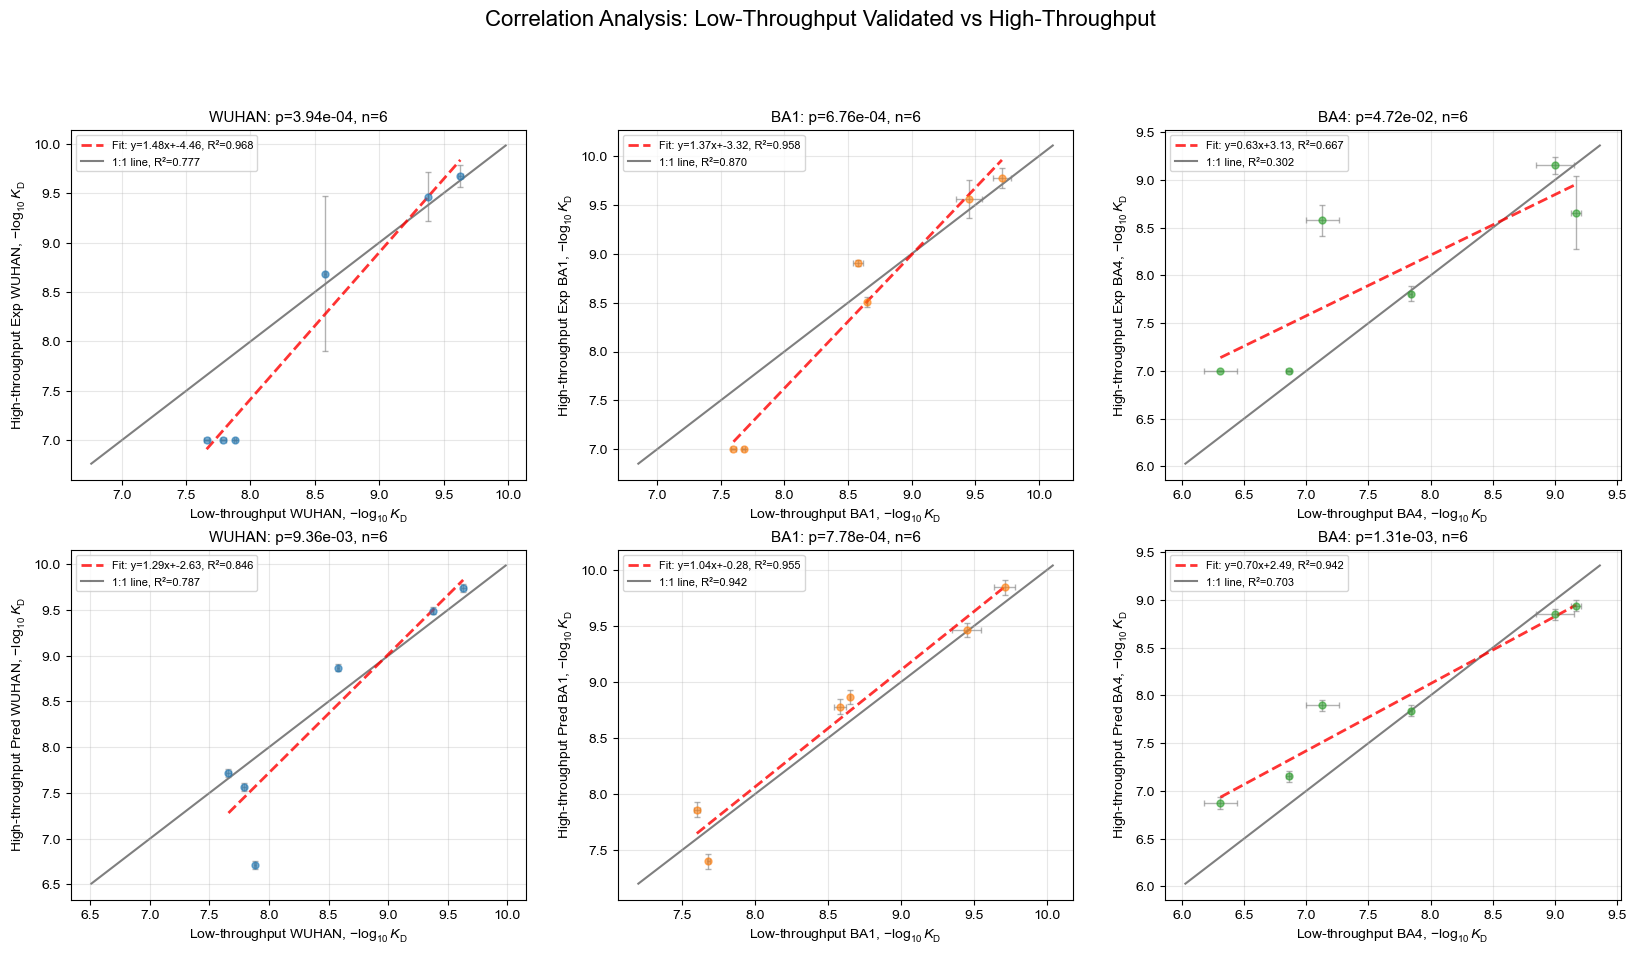

In [10]:
# Create figure with subplots for correlation analysis for each antigen
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Correlation Analysis: Low-Throughput Validated vs High-Throughput', fontsize=16, y=1.00)

# Define antigens and colors
antigens = ['wuhan', 'ba1', 'ba4']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

lt_cols = {
    'wuhan': ('wuhan_lt_mean', 'wuhan_lt_sem'),
    'ba1': ('ba1_lt_mean', 'ba1_lt_sem'),
    'ba4': ('ba4_lt_mean', 'ba4_lt_sem')
}
ht_exp_cols = {
    'wuhan': ('w_kd_mean_e', 'w_kd_sem_e'),
    'ba1': ('ba1_kd_mean_e', 'ba1_kd_sem_e'),
    'ba4': ('ba4_kd_mean_e', 'ba4_kd_sem_e')
}
ht_pred_cols = {
    'wuhan': ('w_kd_mean_p', 'w_kd_sem_p'),
    'ba1': ('ba1_kd_mean_p', 'ba1_kd_sem_p'),
    'ba4': ('ba4_kd_mean_p', 'ba4_kd_sem_p')
}
# Low-throughput vs High-throughput (by antigen)
for idx, antigen in enumerate(antigens):
    ax = axes[0, idx]
    
    lt_mean, lt_sem = lt_cols[antigen]
    ht_mean, ht_sem = ht_exp_cols[antigen]
    
    # drop rows if either mean values are missing
    data = merged[[lt_mean, lt_sem, ht_mean, ht_sem]].copy()
    data = data.dropna(subset=[lt_mean, ht_mean])
    
    if len(data) > 0:
        x = data[lt_mean].values
        y = data[ht_mean].values
        x_err = data[lt_sem].fillna(0).values
        y_err = data[ht_sem].fillna(0).values
        
        # Calculate Pearson's r and R² for the fitted line
        r_pearson, p_val = pearsonr(x, y)
        r2_fit = r_pearson**2
        
        # Calculate R² for 1:1 line
        ss_res_11 = np.sum((y - x)**2)  # residuals from 1:1 line
        ss_tot = np.sum((y - np.mean(y))**2)
        r2_11 = 1 - (ss_res_11 / ss_tot)
        
        ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', alpha=0.6, 
                    markersize=5, color=colors[idx], ecolor='gray', 
                    elinewidth=1, capsize=2)
        
        z = np.polyfit(x, y, 1)
        p_line = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p_line(x_line), "r--", alpha=0.8, linewidth=2, 
                label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}, R²={r2_fit:.3f}')
        
        # Add diagonal line (y=x)
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),
            np.max([ax.get_xlim(), ax.get_ylim()]),
        ]
        ax.plot(lims, lims, 'k-', alpha=0.5, zorder=0, linewidth=1.5, 
                label=f'1:1 line, R²={r2_11:.3f}')
        
        ax.set_xlabel('Low-throughput ' + antigen.upper() + r', $-\log_{10} K_{\mathrm{D}}$', fontsize=10)
        ax.set_ylabel('High-throughput Exp ' + antigen.upper() + r', $-\log_{10} K_{\mathrm{D}}$', fontsize=10)
        ax.set_title(f'{antigen.upper()}: p={p_val:.2e}, n={len(data)}', fontsize=11)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)

# Low-throughput vs Predicted (by antigen)
for idx, antigen in enumerate(antigens):
    ax = axes[1, idx]
    
    lt_mean, lt_sem = lt_cols[antigen]
    ht_mean, ht_sem = ht_pred_cols[antigen]
    
    # drop rows if either mean values are missing
    data = merged[[lt_mean, lt_sem, ht_mean, ht_sem]].copy()
    data = data.dropna(subset=[lt_mean, ht_mean])
    
    if len(data) > 0:
        x = data[lt_mean].values
        y = data[ht_mean].values
        x_err = data[lt_sem].fillna(0).values
        y_err = data[ht_sem].fillna(0).values
        
        # Calculate Pearson's r and R² for the fitted line
        r_pearson, p_val = pearsonr(x, y)
        r2_fit = r_pearson**2
        
        # Calculate R² for 1:1 line
        ss_res_11 = np.sum((y - x)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2_11 = 1 - (ss_res_11 / ss_tot)
        
        ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', alpha=0.6, 
                    markersize=5, color=colors[idx], ecolor='gray', 
                    elinewidth=1, capsize=2)
        
        z = np.polyfit(x, y, 1)
        p_line = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p_line(x_line), "r--", alpha=0.8, linewidth=2,
                label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}, R²={r2_fit:.3f}')
        
        # Add diagonal line (y=x)
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),
            np.max([ax.get_xlim(), ax.get_ylim()]),
        ]
        ax.plot(lims, lims, 'k-', alpha=0.5, zorder=0, linewidth=1.5,
                label=f'1:1 line, R²={r2_11:.3f}')
        
        ax.set_xlabel('Low-throughput ' + antigen.upper() + r', $-\log_{10} K_{\mathrm{D}}$', fontsize=10)
        ax.set_ylabel('High-throughput Pred ' + antigen.upper() + r', $-\log_{10} K_{\mathrm{D}}$', fontsize=10)
        ax.set_title(f'{antigen.upper()}: p={p_val:.2e}, n={len(data)}', fontsize=11)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
plt.show()


<>:110: SyntaxWarning: invalid escape sequence '\l'
<>:163: SyntaxWarning: invalid escape sequence '\l'
<>:193: SyntaxWarning: invalid escape sequence '\l'
<>:110: SyntaxWarning: invalid escape sequence '\l'
<>:163: SyntaxWarning: invalid escape sequence '\l'
<>:193: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/269876777.py:110: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('low-throughput meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8, labelpad=4)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/269876777.py:163: SyntaxWarning: invalid escape sequence '\l'
  'BioPhy-Seq meas,\n$-\log_{10} K_{\mathrm{D}}$',
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/269876777.py:193: SyntaxWarning: invalid escape sequence '\l'
  'predicted phenotype,\n$-\log_{10} K_{\mathrm{D}}$',



affinity_S_Fig1c:
  Canvas size: 1 × 1 inches
  Total figure size: 3.70 × 3.50 inches
  At 2000 DPI: 7400 × 7000 pixels
  Pearson r = 0.854
  p-value = 6.64e-06
  Orthogonal fit: y = 1.111x + -0.980
  n = 18


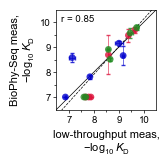


affinity_S_Fig1d:
  Canvas size: 1 × 1 inches
  Total figure size: 3.70 × 3.50 inches
  At 2000 DPI: 7400 × 7000 pixels
  Pearson r = 0.918
  p-value = 8.13e-08
  Orthogonal fit: y = 0.996x + 0.088
  n = 18


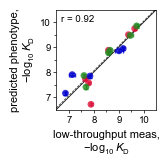


✓ Plots saved successfully!


In [11]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

colorWuhan = "#DC143C"
colorBA1   = "#228B22"
colorBA4   = "#0000CD"

antigens = ['wuhan', 'ba1', 'ba4']
colors = [colorWuhan, colorBA1, colorBA4]

lt_cols = {
    'wuhan': ('wuhan_lt_mean', 'wuhan_lt_sem'),
    'ba1': ('ba1_lt_mean', 'ba1_lt_sem'),
    'ba4': ('ba4_lt_mean', 'ba4_lt_sem')
}
ht_exp_cols = {
    'wuhan': ('w_kd_mean_e', 'w_kd_sem_e'),
    'ba1': ('ba1_kd_mean_e', 'ba1_kd_sem_e'),
    'ba4': ('ba4_kd_mean_e', 'ba4_kd_sem_e')
}
ht_pred_cols = {
    'wuhan': ('w_kd_mean_p', 'w_kd_sem_p'),
    'ba1': ('ba1_kd_mean_p', 'ba1_kd_sem_p'),
    'ba4': ('ba4_kd_mean_p', 'ba4_kd_sem_p')
}
# make low-throughput validation plots for selected intermediates and all antigens combined
def make_combined_plot(data_dict, ylabel, filename, subdirectory):

    CANVAS_WIDTH = 1
    CANVAS_HEIGHT = 1

    LEFT_MARGIN = 0.7
    RIGHT_MARGIN = 2
    TOP_MARGIN = 2
    BOTTOM_MARGIN = 0.5

    # Calculate total figure size
    fig_width = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
    fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = GridSpec(1, 1, figure=fig,
                  left=LEFT_MARGIN/fig_width,
                  right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
                  top=1 - TOP_MARGIN/fig_height,
                  bottom=BOTTOM_MARGIN/fig_height)
    ax = fig.add_subplot(gs[0])
    x = data_dict['x']
    y = data_dict['y']
    point_colors = data_dict['colors']
    xerr = data_dict.get('xerr', None)
    yerr = data_dict.get('yerr', None)

    # Calculate Pearson r
    r_pearson, p_val = pearsonr(x, y)

    if xerr is not None or yerr is not None:
        for xi, yi, xe, ye, ci in zip(
            x,
            y,
            xerr if xerr is not None else [None]*len(x),
            yerr if yerr is not None else [None]*len(y),
            point_colors
        ):
            ax.errorbar(
                xi, yi,
                xerr=xe,
                yerr=ye,
                fmt='none',
                ecolor=ci,
                elinewidth=0.5,
                capsize=1.5,
                alpha=0.8,
                zorder=1
            )

    ax.scatter(x, y, s=24, c=point_colors, alpha=0.8, linewidths=0, zorder=2)
 
    ax.set_xlim(6.5, 10.5)
    ax.set_ylim(6.5, 10.5)
    ax.set_xticks([7, 8, 9, 10])
    ax.set_yticks([7, 8, 9, 10])
    ax.set_xticks([7.5, 8.5, 9.5], minor=True)
    ax.set_yticks([7.5, 8.5, 9.5], minor=True)
    ax.set_aspect('equal', adjustable='box')

    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lims, lims, 'k-', lw=0.5, zorder=0)
   
    x0 = np.asarray(x, float)
    y0 = np.asarray(y, float)
    m = np.isfinite(x0) & np.isfinite(y0)
    x0, y0 = x0[m], y0[m]
    def _f(B, x):
        return B[0] * x + B[1]
    model = odr.Model(_f)
    data = odr.RealData(x0, y0)
    odr_obj = odr.ODR(data, model, beta0=[1.0, 0.0])
    out = odr_obj.run()
    slope, intercept = out.beta
    x_line = np.array(ax.get_xlim())
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=0.5, zorder=1)
    
    ax.set_xlabel('low-throughput meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8, labelpad=4)
    ax.set_ylabel(ylabel, fontsize=8, labelpad=2)
 
    ax.tick_params(axis='both', which='major', labelsize=7, pad=2, length=2, width=0.5, direction='out')
    ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')
  
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
  
    ax.text(0.05, 0.95, f'r = {r_pearson:.2f}',
            transform=ax.transAxes, fontsize=7, va='top', ha='left')

    plt.savefig(f"{subdirectory}/{filename}.png", dpi=2000, bbox_inches='tight', transparent=True)
    
    print(f'\n{filename}:')
    print(f'  Canvas size: {CANVAS_WIDTH} × {CANVAS_HEIGHT} inches')
    print(f'  Total figure size: {fig_width:.2f} × {fig_height:.2f} inches')
    print(f'  At 2000 DPI: {int(fig_width * 2000)} × {int(fig_height * 2000)} pixels')
    print(f'  Pearson r = {r_pearson:.3f}')
    print(f'  p-value = {p_val:.2e}')
    print(f'  Orthogonal fit: y = {slope:.3f}x + {intercept:.3f}')
    print(f'  n = {len(x0)}')
    plt.show()

# Supplemental Figure 1c: LT vs HT Experimental (affinity)
all_lt_exp = []
all_ht_exp = []
all_lt_exp_err = []
all_ht_exp_err = []
all_colors_exp = []
for antigen, color in zip(antigens, colors):
    lt_mean, lt_sem = lt_cols[antigen]
    ht_mean, ht_sem = ht_exp_cols[antigen]
    data = merged[[lt_mean, lt_sem, ht_mean, ht_sem]].copy()
    data = data.dropna(subset=[lt_mean, ht_mean])
    n_points = len(data)
    all_lt_exp.extend(data[lt_mean].values)
    all_ht_exp.extend(data[ht_mean].values)
    all_lt_exp_err.extend(data[lt_sem].fillna(0).values)
    all_ht_exp_err.extend(data[ht_sem].fillna(0).values)
    all_colors_exp.extend([color] * n_points)
if len(all_lt_exp) > 0:
    exp_data = {
        'x': np.array(all_lt_exp),
        'y': np.array(all_ht_exp),
        'xerr': np.array(all_lt_exp_err),
        'yerr': np.array(all_ht_exp_err),
        'colors': all_colors_exp
    }
    make_combined_plot(
        exp_data,
        'BioPhy-Seq meas,\n$-\log_{10} K_{\mathrm{D}}$',
        'affinity_S_Fig1c',S_FIG_1C 
    )
# Supplemental Figure 1d: LT vs Predicted (affinity)
all_lt_pred = []
all_ht_pred = []
all_lt_pred_err = []
all_ht_pred_err = []
all_colors_pred = []
for antigen, color in zip(antigens, colors):
    lt_mean, lt_sem = lt_cols[antigen]
    ht_mean, ht_sem = ht_pred_cols[antigen]
    data = merged[[lt_mean, lt_sem, ht_mean, ht_sem]].copy()
    data = data.dropna(subset=[lt_mean, ht_mean])
    n_points = len(data)
    all_lt_pred.extend(data[lt_mean].values)
    all_ht_pred.extend(data[ht_mean].values)
    all_lt_pred_err.extend(data[lt_sem].fillna(0).values)
    all_ht_pred_err.extend(data[ht_sem].fillna(0).values)
    all_colors_pred.extend([color] * n_points)
if len(all_lt_pred) > 0:
    pred_data = {
        'x': np.array(all_lt_pred),
        'y': np.array(all_ht_pred),
        'xerr': np.array(all_lt_pred_err),
        'yerr': np.array(all_ht_pred_err),
        'colors': all_colors_pred
    }
    make_combined_plot(
        pred_data,
        'predicted phenotype,\n$-\log_{10} K_{\mathrm{D}}$',
        'affinity_S_Fig1d',S_FIG_1D 
    )
print("\n✓ Plots saved successfully!")


<>:121: SyntaxWarning: invalid escape sequence '\l'
<>:122: SyntaxWarning: invalid escape sequence '\l'
<>:121: SyntaxWarning: invalid escape sequence '\l'
<>:122: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/1781029081.py:121: SyntaxWarning: invalid escape sequence '\l'
  xlabel='BioPhy-Seq meas,\n$-\log_{10} K_{\mathrm{D}}$',
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/1781029081.py:122: SyntaxWarning: invalid escape sequence '\l'
  ylabel='predicted phenotype,\n$-\log_{10} K_{\mathrm{D}}$',



wuhan_affinity_S_Fig1b:
  Canvas size: 1 × 1 inches
  Total figure size: 2.20 × 2.50 inches
  At 2000 DPI: 4400 × 5000 pixels
  Pearson r = 0.902
  p-value = 0.00e+00
  Linear fit: y = 0.814x + 1.623
  n = 6740


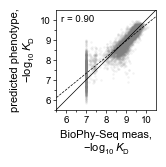


ba1_affinity_S_Fig1b:
  Canvas size: 1 × 1 inches
  Total figure size: 2.20 × 2.50 inches
  At 2000 DPI: 4400 × 5000 pixels
  Pearson r = 0.907
  p-value = 0.00e+00
  Linear fit: y = 0.823x + 1.622
  n = 7037


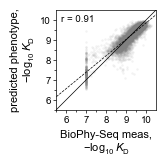


ba4_affinity_S_Fig1b:
  Canvas size: 1 × 1 inches
  Total figure size: 2.20 × 2.50 inches
  At 2000 DPI: 4400 × 5000 pixels
  Pearson r = 0.938
  p-value = 0.00e+00
  Linear fit: y = 0.880x + 0.983
  n = 7416


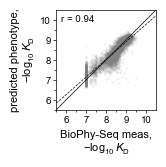


✓ Plots saved successfully!


In [12]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

colorWuhan = "#DC143C"
colorBA1   = "#228B22"
colorBA4   = "#0000CD"
antigens = ['wuhan', 'ba1', 'ba4']
colors = [colorWuhan, colorBA1, colorBA4]

ht_exp_cols = {
    'wuhan': ('w_kd_mean_e', 'w_kd_sem_e'),
    'ba1': ('ba1_kd_mean_e', 'ba1_kd_sem_e'),
    'ba4': ('ba4_kd_mean_e', 'ba4_kd_sem_e')
}
ht_pred_cols = {
    'wuhan': ('w_kd_mean_p', 'w_kd_sem_p'),
    'ba1': ('ba1_kd_mean_p', 'ba1_kd_sem_p'),
    'ba4': ('ba4_kd_mean_p', 'ba4_kd_sem_p')
}

# make high-throughput vs predicted affinity plots for each antigen
def make_single_antigen_plot(x, y, xlabel, ylabel, filename, directory):
    # drop paired NaNs
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) == 0:
        print(f"[WARN] {filename}: no paired points")
        return
    # Calculate Pearson r
    r_pearson, p_val = pearsonr(x, y)

    # Calculate linear regression for correlation line
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
   
    CANVAS_WIDTH = 1
    CANVAS_HEIGHT = 1
    
    LEFT_MARGIN = 0.7
    RIGHT_MARGIN = 0.5
    TOP_MARGIN = 1
    BOTTOM_MARGIN = 0.5

    # Calculate total figure size
    fig_width = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
    fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = GridSpec(1, 1, figure=fig,
                  left=LEFT_MARGIN/fig_width,
                  right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
                  top=1 - TOP_MARGIN/fig_height,
                  bottom=BOTTOM_MARGIN/fig_height)

    ax = fig.add_subplot(gs[0])
    ax.scatter(x, y, s=3, alpha=0.1, color='gray', linewidths=0)

    ax.set_xlim(5.5, 10.5)
    ax.set_ylim(5.5, 10.5)
    ax.set_xticks([6, 7, 8, 9, 10])
    ax.set_yticks([6, 7, 8, 9, 10])
    ax.set_xticks([5.5, 6.5, 7.5, 8.5, 9.5], minor=True)
    ax.set_yticks([5.5, 6.5, 7.5, 8.5, 9.5], minor=True)
    ax.set_aspect('equal', adjustable='box')
   
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lims, lims, 'k-', lw=0.5)
   
    x_line = np.array(ax.get_xlim())
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'k--', lw=0.5)
   
    ax.set_xlabel(xlabel, fontsize=8, labelpad=4)
    ax.set_ylabel(ylabel, fontsize=8, labelpad=2)
 
    ax.tick_params(axis='both', which='major', labelsize=7, pad=2, length=2, width=0.5, direction='out')
    ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')

    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    
    ax.text(0.05, 0.95, f'r = {r_pearson:.2f}',
            transform=ax.transAxes,
            fontsize=7,
            va='top',
            ha='left')
 
    plt.savefig(f"{directory}/{filename}.png", dpi=2000, bbox_inches='tight', transparent=True)
    
    print(f'\n{filename}:')
    print(f'  Canvas size: {CANVAS_WIDTH} × {CANVAS_HEIGHT} inches')
    print(f'  Total figure size: {fig_width:.2f} × {fig_height:.2f} inches')
    print(f'  At 2000 DPI: {int(fig_width * 2000)} × {int(fig_height * 2000)} pixels')
    print(f'  Pearson r = {r_pearson:.3f}')
    print(f'  p-value = {p_val:.2e}')
    print(f'  Linear fit: y = {slope:.3f}x + {intercept:.3f}')
    print(f'  n = {len(x)}')
    plt.show()

# Predicted vs HT data — one plot per antigen
for antigen in antigens:
    exp_mean, exp_sem = ht_exp_cols[antigen]
    pred_mean, pred_sem = ht_pred_cols[antigen]
    data = ht_exp[['geno', exp_mean]].merge(
        ht_pred[['geno', pred_mean]],
        on='geno', how='inner'
    ).dropna(subset=[exp_mean, pred_mean])
    make_single_antigen_plot(
        x=data[exp_mean].values,
        y=data[pred_mean].values,
        xlabel='BioPhy-Seq meas,\n$-\log_{10} K_{\mathrm{D}}$',
        ylabel='predicted phenotype,\n$-\log_{10} K_{\mathrm{D}}$',
        filename=f'{antigen}_affinity_S_Fig1b',
        directory=S_FIG_1B
    )
print("\n✓ Plots saved successfully!")


## Polyspecificity Comparisons


In [13]:
# correlation summaries

# LT vs HT
lt_expr_psr = merged_psr[['mean_log_EC50_lt', 'sem_log_EC50',
                          'mean_EC50_3p', 'SEM_EC50_3p']].dropna()
lt_vals_expr     = lt_expr_psr['mean_log_EC50_lt'].values
expr_vals        = lt_expr_psr['mean_EC50_3p'].values
lt_sem_expr      = lt_expr_psr['sem_log_EC50'].values
expr_sem_vals    = lt_expr_psr['SEM_EC50_3p'].values

# LT vs Predicted
lt_pred_psr = merged_psr[['mean_log_EC50_lt', 'sem_log_EC50',
                          'mean_EC50_3p_pred', 'SEM_EC50_3p_pred']].dropna()
lt_vals_pred     = lt_pred_psr['mean_log_EC50_lt'].values
pred_vals        = lt_pred_psr['mean_EC50_3p_pred'].values
lt_sem_pred      = lt_pred_psr['sem_log_EC50'].values
pred_sem_vals    = lt_pred_psr['SEM_EC50_3p_pred'].values


# print stats
if len(lt_vals_expr) > 2:
    r_psr_expr, p_r_psr_expr = pearsonr(lt_vals_expr, expr_vals)
    rho_psr_expr, p_rho_psr_expr = spearmanr(lt_vals_expr, expr_vals)
    slope_psr_expr, intercept_psr_expr, _, _, _ = linregress(lt_vals_expr, expr_vals)
    print(f"PSR LT vs Experimental: r={r_psr_expr:.3f}, p={p_r_psr_expr:.2e}, ρ={rho_psr_expr:.3f}, p_ρ={p_rho_psr_expr:.2e}, n={len(lt_vals_expr)}")
else:
    r_psr_expr, p_r_psr_expr = np.nan, np.nan
    rho_psr_expr, p_rho_psr_expr = np.nan, np.nan
    slope_psr_expr, intercept_psr_expr = np.nan, np.nan

if len(lt_vals_pred) > 2:
    r_psr_pred, p_r_psr_pred = pearsonr(lt_vals_pred, pred_vals)
    rho_psr_pred, p_rho_psr_pred = spearmanr(lt_vals_pred, pred_vals)
    slope_psr_pred, intercept_psr_pred, _, _, _ = linregress(lt_vals_pred, pred_vals)
    print(f"PSR LT vs Predicted: r={r_psr_pred:.3f}, p={p_r_psr_pred:.2e}, ρ={rho_psr_pred:.3f}, p_ρ={p_rho_psr_pred:.2e}, n={len(lt_vals_pred)}")
else:
    r_psr_pred, p_r_psr_pred = np.nan, np.nan
    rho_psr_pred, p_rho_psr_pred = np.nan, np.nan
    slope_psr_pred, intercept_psr_pred = np.nan, np.nan



PSR LT vs Experimental: r=0.606, p=6.31e-02, ρ=0.503, p_ρ=1.38e-01, n=10
PSR LT vs Predicted: r=0.881, p=7.64e-04, ρ=0.758, p_ρ=1.11e-02, n=10


<>:88: SyntaxWarning: invalid escape sequence '\l'
<>:117: SyntaxWarning: invalid escape sequence '\l'
<>:128: SyntaxWarning: invalid escape sequence '\l'
<>:88: SyntaxWarning: invalid escape sequence '\l'
<>:117: SyntaxWarning: invalid escape sequence '\l'
<>:128: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/831591402.py:88: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('low-throughput meas,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$', fontsize=8, labelpad=2)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/831591402.py:117: SyntaxWarning: invalid escape sequence '\l'
  ylabel='BioPhy-Seq meas,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$',
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/831591402.py:128: SyntaxWarning: invalid escape sequence '\l'
  ylabel='predicted phenotype,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$',



polyreactivity_S_Fig_1c:
  Canvas size: 1 × 1 inches
  Total figure size: 1.90 × 1.70 inches
  At 2000 DPI: 3800 × 3400 pixels
  Pearson r = 0.606
  p-value = 6.31e-02
  Orthogonal fit: y = 3.218x + -1.974
  n = 10


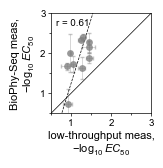


polyreactivity_S_Fig_1d:
  Canvas size: 1 × 1 inches
  Total figure size: 1.90 × 1.70 inches
  At 2000 DPI: 3800 × 3400 pixels
  Pearson r = 0.881
  p-value = 7.64e-04
  Orthogonal fit: y = 1.611x + -0.231
  n = 10


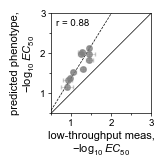


✓ Polyreactivity correlation plots saved successfully!


In [14]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

# make low-throughput validation plots
def make_polyreactivity_plot(x_data, y_data, ylabel, filename, directory,
                             xerr=None, yerr=None, point_color='gray'):
    """
    Styled polyreactivity correlation plot with optional colored error bars.
    """
    
    CANVAS_WIDTH = 1
    CANVAS_HEIGHT = 1
  
    LEFT_MARGIN = 0.7
    RIGHT_MARGIN = 0.2
    TOP_MARGIN = 0.2
    BOTTOM_MARGIN = 0.5

    # Calculate total figure size
    fig_width = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
    fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = GridSpec(1, 1, figure=fig,
                  left=LEFT_MARGIN/fig_width,
                  right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
                  top=1 - TOP_MARGIN/fig_height,
                  bottom=BOTTOM_MARGIN/fig_height)
    ax = fig.add_subplot(gs[0])

    x = np.asarray(x_data, float)
    y = np.asarray(y_data, float)
    xe = None if xerr is None else np.asarray(xerr, float)
    ye = None if yerr is None else np.asarray(yerr, float)
    m = np.isfinite(x) & np.isfinite(y)
    if xe is not None:
        m = m & np.isfinite(xe)
    if ye is not None:
        m = m & np.isfinite(ye)
    x = x[m]; y = y[m]
    if xe is not None: xe = xe[m]
    if ye is not None: ye = ye[m]

    # Pearson r
    r_pearson, p_val = pearsonr(x, y)
  
    if xe is not None or ye is not None:
        ax.errorbar(
            x, y,
            xerr=xe, yerr=ye,
            fmt='none',
            ecolor=point_color,
            elinewidth=0.5,
            capsize=1.5,
            alpha=0.45,
            zorder=1
        )
 
    ax.scatter(x, y, s=24, alpha=0.8, color=point_color, linewidths=0, zorder=2)

    ax.set_xlim(0.5, 3)
    ax.set_ylim(0.5, 3)
    ax.set_xticks([1, 2, 3])
    ax.set_yticks([1, 2, 3])
    ax.set_xticks([0.5, 1.5, 2.5], minor=True)
    ax.set_yticks([0.5, 1.5, 2.5], minor=True)
    ax.set_aspect('equal', adjustable='box')

    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lims, lims, 'k-', lw=0.5, zorder=0)

    def _f(B, x_):
        return B[0] * x_ + B[1]
    model = odr.Model(_f)
    data = odr.RealData(x, y)
    odr_obj = odr.ODR(data, model, beta0=[1.0, 0.0])
    out = odr_obj.run()
    slope, intercept = out.beta
    x_line = np.array(ax.get_xlim())
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=0.5, zorder=1)
  
    ax.set_xlabel('low-throughput meas,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$', fontsize=8, labelpad=2)
    ax.set_ylabel(ylabel, fontsize=8, labelpad=2)
    
    ax.tick_params(axis='both', which='major', labelsize=7, pad=2, length=2, width=0.5, direction='out')
    ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')
  
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    ax.text(0.05, 0.95, f'r = {r_pearson:.2f}',
            transform=ax.transAxes, fontsize=7, va='top', ha='left')
 
    plt.savefig(f"{directory}/{filename}.png", dpi=2000, bbox_inches='tight', transparent=True)
  
    print(f'\n{filename}:')
    print(f'  Canvas size: {CANVAS_WIDTH} × {CANVAS_HEIGHT} inches')
    print(f'  Total figure size: {fig_width:.2f} × {fig_height:.2f} inches')
    print(f'  At 2000 DPI: {int(fig_width * 2000)} × {int(fig_height * 2000)} pixels')
    print(f'  Pearson r = {r_pearson:.3f}')
    print(f'  p-value = {p_val:.2e}')
    print(f'  Orthogonal fit: y = {slope:.3f}x + {intercept:.3f}')
    print(f'  n = {len(x)}')
    plt.show()

# LT vs HT Polyreactivity
make_polyreactivity_plot(
    lt_vals_expr, expr_vals,
    ylabel='BioPhy-Seq meas,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$',
    filename='polyreactivity_S_Fig_1c',
    directory=S_FIG_1C,
    xerr=lt_sem_expr,          
    yerr=expr_sem_vals,       
    point_color='gray'
)

# LT vs Predicted Polyreactivity
make_polyreactivity_plot(
    lt_vals_pred, pred_vals,
    ylabel='predicted phenotype,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$',
    filename='polyreactivity_S_Fig_1d',
    directory=S_FIG_1D,
    xerr=lt_sem_pred,          
    yerr=pred_sem_vals,        
    point_color='gray'
)
print("\n✓ Polyreactivity correlation plots saved successfully!")



polyreactivity_S_Fig_1b: paired N = 5510
  x range: -0.4274 .. 3.04
  y range: 0.9669 .. 2.229
  Pearson r = 0.603
  p-value   = 0.00e+00
  ODR fit   = y = 0.454x + 0.942


<>:72: SyntaxWarning: invalid escape sequence '\l'
<>:99: SyntaxWarning: invalid escape sequence '\l'
<>:72: SyntaxWarning: invalid escape sequence '\l'
<>:99: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/3229906249.py:72: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('BioPhy-Seq meas,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$', fontsize=8, labelpad=4)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/3229906249.py:99: SyntaxWarning: invalid escape sequence '\l'
  'predicted phenotype,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$',


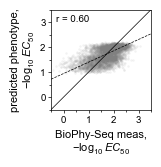

In [15]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

# plot HT vs Predicted correlation plots (S Figure 1b) for polyreactivity
def make_polyreactivity_plot(x_data, y_data, ylabel, filename, directory):
   
    x0 = np.asarray(x_data, float)
    y0 = np.asarray(y_data, float)
    m = np.isfinite(x0) & np.isfinite(y0)
    x0, y0 = x0[m], y0[m]
    print(f"\n{filename}: paired N = {len(x0)}")
    if len(x0) == 0:
        print("[WARN] No paired points after merge/dropna. Check geno overlap and column names.")
        return
    print(f"  x range: {x0.min():.4g} .. {x0.max():.4g}")
    print(f"  y range: {y0.min():.4g} .. {y0.max():.4g}")

    # Pearson r
    r_pearson, p_val = pearsonr(x0, y0)
    
    def _f(B, x):
        return B[0] * x + B[1]  
    model = odr.Model(_f)
    data = odr.RealData(x0, y0) 
    odr_obj = odr.ODR(data, model, beta0=[1.0, 0.0])
    out = odr_obj.run()
    slope, intercept = out.beta
   
    CANVAS_WIDTH = 1
    CANVAS_HEIGHT = 1

    LEFT_MARGIN = 0.7
    RIGHT_MARGIN = 0.2
    TOP_MARGIN = 0.2
    BOTTOM_MARGIN = 0.5

    fig_width = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
    fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = GridSpec(
        1, 1, figure=fig,
        left=LEFT_MARGIN/fig_width,
        right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
        top=1 - TOP_MARGIN/fig_height,
        bottom=BOTTOM_MARGIN/fig_height
    )
    ax = fig.add_subplot(gs[0])

    ax.scatter(x0, y0, s=3, alpha=0.1, color='gray', linewidths=0)

    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.5, 3.5)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_yticks([0, 1, 2, 3])
    ax.set_xticks([-0.5, 0.5, 1.5, 2.5, 3.5], minor=True)
    ax.set_yticks([-0.5, 0.5, 1.5, 2.5, 3.5], minor=True)
    ax.set_aspect('equal', adjustable='box')

    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lims, lims, 'k-', lw=0.5)
  
    x_line = np.array(ax.get_xlim())
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=0.5)

    ax.set_xlabel('BioPhy-Seq meas,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$', fontsize=8, labelpad=4)
    ax.set_ylabel(ylabel, fontsize=8, labelpad=2)

    ax.tick_params(axis='both', which='major', labelsize=7, pad=2, length=2, width=0.5, direction='out')
    ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')

    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    ax.text(0.05, 0.95, f'r = {r_pearson:.2f}',
            transform=ax.transAxes, fontsize=7, va='top', ha='left')
    #plt.savefig(f"{directory}/{filename}.png", dpi=2000, bbox_inches='tight', transparent=True)
   
    print(f"  Pearson r = {r_pearson:.3f}")
    print(f"  p-value   = {p_val:.2e}")
    print(f"  ODR fit   = y = {slope:.3f}x + {intercept:.3f}")
    plt.show()

# HT vs Predicted — merge on geno and plot all paired points
data = psr_expr.merge(psr_pred, on='geno', how='inner').dropna(
    subset=['mean_EC50_3p', 'mean_EC50_3p_pred']
)
make_polyreactivity_plot(
    data['mean_EC50_3p'].values,
    data['mean_EC50_3p_pred'].values,
    'predicted phenotype,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$',
    'polyreactivity_S_Fig_1b',
    S_FIG_1B
)
#print("\n✓ Polyreactivity correlation plot saved successfully!")



polyreactivity_S_Fig_1b: paired N = 5510
  x range: -0.4274 .. 3.04
  y range: 0.9669 .. 2.229


<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:112: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:112: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/3377143989.py:79: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('BioPhy-Seq meas,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$', fontsize=8, labelpad=4)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/3377143989.py:112: SyntaxWarning: invalid escape sequence '\l'
  'predicted phenotype,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$',
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/3377143989.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6, markerscale=2, frameon=False,


  Pearson r = 0.603
  p-value   = 0.00e+00
  ODR fit   = y = 0.454x + 0.942


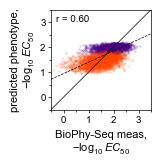


✓ Polyreactivity correlation plot saved successfully!


In [16]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

# plot HT vs Predicted correlation plots (S Figure 1b) for polyreactivity and label points by whether they have I51Y, the mutation that impars the strongest decrease in polyspecificity 
def make_polyreactivity_plot(x_data, y_data, geno_data, ylabel, filename, directory):
    
    x0 = np.asarray(x_data, float)
    y0 = np.asarray(y_data, float)
    geno = np.asarray(geno_data)
    m = np.isfinite(x0) & np.isfinite(y0)
    x0, y0, geno = x0[m], y0[m], geno[m]
    print(f"\n{filename}: paired N = {len(x0)}")
    if len(x0) == 0:
        print("[WARN] No paired points after merge/dropna. Check geno overlap and column names.")
        return
    print(f"  x range: {x0.min():.4g} .. {x0.max():.4g}")
    print(f"  y range: {y0.min():.4g} .. {y0.max():.4g}")

    # Color mask: I51Y - position 3 (index 2) in geno string
    mask_1 = np.array([str(g)[2] == '1' for g in geno])
    mask_0 = ~mask_1

    # Pearson r
    r_pearson, p_val = pearsonr(x0, y0)
  
    def _f(B, x):
        return B[0] * x + B[1]
    model = odr.Model(_f)
    data_odr = odr.RealData(x0, y0)
    odr_obj = odr.ODR(data_odr, model, beta0=[1.0, 0.0])
    out = odr_obj.run()
    slope, intercept = out.beta
 
    CANVAS_WIDTH = 1
    CANVAS_HEIGHT = 1

    LEFT_MARGIN = 0.7
    RIGHT_MARGIN = 0.2
    TOP_MARGIN = 0.2
    BOTTOM_MARGIN = 0.5

    fig_width = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
    fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = GridSpec(
        1, 1, figure=fig,
        left=LEFT_MARGIN/fig_width,
        right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
        top=1 - TOP_MARGIN/fig_height,
        bottom=BOTTOM_MARGIN/fig_height
    )
    ax = fig.add_subplot(gs[0])

    # Scatter: colored by presence (orange) or absence (purple) of I51Y in geno
    ax.scatter(x0[mask_0], y0[mask_0], s=3, alpha=0.2, color='#4B0082',  linewidths=0)
    ax.scatter(x0[mask_1], y0[mask_1], s=3, alpha=0.2, color='#FF4500',     linewidths=0)
    
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.5, 3.5)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_yticks([0, 1, 2, 3])
    ax.set_xticks([-0.5, 0.5, 1.5, 2.5, 3.5], minor=True)
    ax.set_yticks([-0.5, 0.5, 1.5, 2.5, 3.5], minor=True)
    ax.set_aspect('equal', adjustable='box')

    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lims, lims, 'k-', lw=0.5)

    x_line = np.array(ax.get_xlim())
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=0.5)

    ax.set_xlabel('BioPhy-Seq meas,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$', fontsize=8, labelpad=4)
    ax.set_ylabel(ylabel, fontsize=8, labelpad=2)

    ax.tick_params(axis='both', which='major', labelsize=7, pad=2, length=2, width=0.5, direction='out')
    ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')

    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    ax.text(0.05, 0.95, f'r = {r_pearson:.2f}',
            transform=ax.transAxes, fontsize=7, va='top', ha='left')
   
    ax.legend(fontsize=6, markerscale=2, frameon=False,
              loc='lower right', handletextpad=0.3, borderpad=0)

    plt.savefig(f"{directory}/{filename}.png", dpi=2000, bbox_inches='tight', transparent=True)
    
    print(f"  Pearson r = {r_pearson:.3f}")
    print(f"  p-value   = {p_val:.2e}")
    print(f"  ODR fit   = y = {slope:.3f}x + {intercept:.3f}")
    plt.show()
# =========================================================
# Experimental vs Predicted
# =========================================================
data = psr_expr.merge(psr_pred, on='geno', how='inner').dropna(
    subset=['mean_EC50_3p', 'mean_EC50_3p_pred']
)
make_polyreactivity_plot(
    data['mean_EC50_3p'].values,
    data['mean_EC50_3p_pred'].values,
    data['geno'].values,          # <-- new argument
    'predicted phenotype,\n$-\log_{10} \mathit{EC}_{\mathrm{50}}$',
    'polyreactivity_S_Fig_1b',
    S_FIG_1B
)
print("\n✓ Polyreactivity correlation plot saved successfully!")


In [17]:
# Save polyreactivity correlation results to CSV
psr_corr_summary = pd.DataFrame([
    {
        'comparison': 'PSR_LT_vs_Experimental',
        'pearson_r': r_psr_expr,
        'pearson_p': p_r_psr_expr,
        'spearman_rho': rho_psr_expr,
        'spearman_p': p_rho_psr_expr,
        'n': len(lt_vals_expr),
        'slope': slope_psr_expr,
        'intercept': intercept_psr_expr
    },
    {
        'comparison': 'PSR_LT_vs_Predicted',
        'pearson_r': r_psr_pred,
        'pearson_p': p_r_psr_pred,
        'spearman_rho': rho_psr_pred,
        'spearman_p': p_rho_psr_pred,
        'n': len(lt_vals_pred),
        'slope': slope_psr_pred,
        'intercept': intercept_psr_pred
    }
])
psr_corr_summary.to_csv('analysis/polyreactivity_correlations.csv', index=False)
print("\nSaved polyreactivity correlation statistics to: polyreactivity_correlations.csv")
print(psr_corr_summary)




Saved polyreactivity correlation statistics to: polyreactivity_correlations.csv
               comparison  pearson_r  pearson_p  spearman_rho  spearman_p   n  \
0  PSR_LT_vs_Experimental   0.606373   0.063099      0.503030    0.138334  10   
1     PSR_LT_vs_Predicted   0.880769   0.000764      0.757576    0.011143  10   

      slope  intercept  
0  1.342725   0.275310  
1  1.344668   0.087733  


## Expression Comparisons


In [18]:
# Load the expression datasets with deltas if not already in memory
try:
    expr_expr
    expr_pred
    expression_df
except NameError:
    print("Loading expression data from CSVs...")
    expr_expr = pd.read_csv('analysis/ht_expression_with_deltas.csv')
    expr_pred = pd.read_csv('analysis/pred_expression_with_deltas.csv')
    if 'geno' in expr_expr.columns:
        expr_expr['geno'] = expr_expr['geno'].astype(str).str.zfill(13)
    if 'geno' in expr_pred.columns:
        expr_pred['geno'] = expr_pred['geno'].astype(str).str.zfill(13)
    expression_df = pd.read_csv('../../BioPhy-Seq_measurements/isogenic_low-throughput_measurements/polyspecificity_and_expression/analysis/omi_lt_expression-analysis.csv')
    print(f"Loaded expression data")

# First, merge the datasets on antibody name
# Merge low-throughput with high-throughput
lt_expr_merged = expression_df.merge(expr_expr, on='antibody', how='inner', suffixes=('_lt', '_expr'))

# Merge low-throughput with predicted
lt_pred_merged = expression_df.merge(expr_pred, on='antibody', how='inner', suffixes=('_lt', '_pred'))
print(f"Merged {len(lt_expr_merged)} antibodies for LT vs Experimental comparison")
print(f"Merged {len(lt_pred_merged)} antibodies for LT vs Predicted comparison")


Loading expression data from CSVs...
Loaded expression data
Merged 10 antibodies for LT vs Experimental comparison
Merged 10 antibodies for LT vs Predicted comparison


In [19]:
# Per-antibody delta correlations (Pearson + Spearman)

antibodies_to_compare = expression_df['antibody'].unique()

per_ab_correlations = []

for ref_antibody in antibodies_to_compare:
    lt_col   = f'mean_delta_ab_{ref_antibody}'
    expr_col = f'delta_ab_{ref_antibody}_expr'
    pred_col = f'delta_ab_{ref_antibody}_pred'

    if lt_col not in expression_df.columns:
        continue

    # LT vs Experimental 
    if expr_col in expr_expr.columns:
        merged_expr = lt_expr_merged[[lt_col, expr_col]].copy()
        merged_expr = merged_expr[merged_expr['antibody'] != ref_antibody] if 'antibody' in merged_expr.columns else \
                      merged_expr[(merged_expr[lt_col] != 0) | (merged_expr[expr_col] != 0)]
        merged_expr = merged_expr.dropna()
        if len(merged_expr) > 2:
            r_expr,   p_expr   = scipy.stats.pearsonr(merged_expr[lt_col], merged_expr[expr_col])
            rho_expr, p_rho_expr = spearmanr(merged_expr[lt_col], merged_expr[expr_col])
        else:
            r_expr = p_expr = rho_expr = p_rho_expr = np.nan
    else:
        r_expr = p_expr = rho_expr = p_rho_expr = np.nan

    # LT vs Predicted 
    if pred_col in expr_pred.columns:
        merged_pred = lt_pred_merged[[lt_col, pred_col]].copy()
        merged_pred = merged_pred[merged_pred['antibody'] != ref_antibody] if 'antibody' in merged_pred.columns else \
                      merged_pred[(merged_pred[lt_col] != 0) | (merged_pred[pred_col] != 0)]
        merged_pred = merged_pred.dropna()
        if len(merged_pred) > 2:
            r_pred,   p_pred   = scipy.stats.pearsonr(merged_pred[lt_col], merged_pred[pred_col])
            rho_pred, p_rho_pred = spearmanr(merged_pred[lt_col], merged_pred[pred_col])
        else:
            r_pred = p_pred = rho_pred = p_rho_pred = np.nan
    else:
        r_pred = p_pred = rho_pred = p_rho_pred = np.nan

    # Experimental vs Predicted 
    if expr_col in expr_expr.columns and pred_col in expr_pred.columns:
        # Merge expr and pred on antibody using lt_expr_merged as the alignment frame
        merged_ep = lt_expr_merged[['antibody', expr_col]].merge(
                        lt_pred_merged[['antibody', pred_col]], on='antibody')
        merged_ep = merged_ep[merged_ep['antibody'] != ref_antibody]
        merged_ep = merged_ep[[expr_col, pred_col]].dropna()
        merged_ep = merged_ep[(merged_ep[expr_col] != 0) | (merged_ep[pred_col] != 0)]
        if len(merged_ep) > 2:
            r_ep,   p_ep   = scipy.stats.pearsonr(merged_ep[expr_col], merged_ep[pred_col])
            rho_ep, p_rho_ep = spearmanr(merged_ep[expr_col], merged_ep[pred_col])
        else:
            r_ep = p_ep = rho_ep = p_rho_ep = np.nan
    else:
        r_ep = p_ep = rho_ep = p_rho_ep = np.nan

    per_ab_correlations.append({
        'reference_antibody': ref_antibody,
        'r_LT_vs_Expr':       r_expr,    'p_LT_vs_Expr':       p_expr,
        'rho_LT_vs_Expr':     rho_expr,  'p_rho_LT_vs_Expr':   p_rho_expr,
        'n_LT_vs_Expr':       len(merged_expr) if not merged_expr.empty else 0,
        'r_LT_vs_Pred':       r_pred,    'p_LT_vs_Pred':       p_pred,
        'rho_LT_vs_Pred':     rho_pred,  'p_rho_LT_vs_Pred':   p_rho_pred,
        'n_LT_vs_Pred':       len(merged_pred) if not merged_pred.empty else 0,
        'r_Expr_vs_Pred':     r_ep,      'p_Expr_vs_Pred':     p_ep,
        'rho_Expr_vs_Pred':   rho_ep,    'p_rho_Expr_vs_Pred': p_rho_ep,
        'n_Expr_vs_Pred':     len(merged_ep) if not merged_ep.empty else 0,
    })

per_ab_corr_df = pd.DataFrame(per_ab_correlations)
print("Per-antibody delta correlations (Pearson + Spearman, all 3 comparisons):")
print(per_ab_corr_df[['reference_antibody',
                        'r_LT_vs_Expr', 'r_LT_vs_Pred', 'r_Expr_vs_Pred',
                        'n_LT_vs_Expr', 'n_LT_vs_Pred', 'n_Expr_vs_Pred']])



Per-antibody delta correlations (Pearson + Spearman, all 3 comparisons):
  reference_antibody  r_LT_vs_Expr  r_LT_vs_Pred  r_Expr_vs_Pred  \
0               2205      0.443651      0.899868        0.581621   
1               6396      0.346255      0.852580        0.482310   
2               5173      0.694701      0.823961        0.713128   
3               6432      0.416679      0.863987        0.542066   
4               4628      0.479610      0.902195        0.550067   
5               4034      0.413930      0.890934        0.544949   
6               5377      0.410543      0.866027        0.586301   
7               5469      0.421821      0.913166        0.489981   
8           GERMLINE      0.470725      0.879409        0.615636   
9              OMI32      0.439186      0.871489        0.555258   

   n_LT_vs_Expr  n_LT_vs_Pred  n_Expr_vs_Pred  
0             9             9               9  
1             9             9               9  
2             9             9     

In [20]:
per_ab_corr_df.loc[per_ab_corr_df['reference_antibody'] == 'GERMLINE', 'reference_antibody'] = 'germline'
per_ab_corr_df.loc[per_ab_corr_df['reference_antibody'] == 'OMI32', 'reference_antibody'] = 'Omi32'
per_ab_corr_df


,reference_antibody,r_LT_vs_Expr,p_LT_vs_Expr,rho_LT_vs_Expr,p_rho_LT_vs_Expr,n_LT_vs_Expr,r_LT_vs_Pred,p_LT_vs_Pred,rho_LT_vs_Pred,p_rho_LT_vs_Pred,n_LT_vs_Pred,r_Expr_vs_Pred,p_Expr_vs_Pred,rho_Expr_vs_Pred,p_rho_Expr_vs_Pred,n_Expr_vs_Pred
0,2205,0.443651,0.231628,0.733333,0.024554,9,0.899868,0.000947,0.916667,0.000507,9,0.581621,0.100424,0.666667,0.049867,9
1,6396,0.346255,0.361343,0.516667,0.154390,9,0.852580,0.003496,0.850000,0.003705,9,0.482310,0.188543,0.333333,0.380713,9
2,5173,0.694701,0.037811,0.650000,0.058073,9,0.823961,0.006315,0.850000,0.003705,9,0.713128,0.031023,0.500000,0.170471,9
3,6432,0.416679,0.264570,0.650000,0.058073,9,0.863987,0.002668,0.900000,0.000943,9,0.542066,0.131647,0.533333,0.139227,9
4,4628,0.479610,0.191393,0.783333,0.012520,9,0.902195,0.000875,0.866667,0.002495,9,0.550067,0.124921,0.566667,0.111633,9
5,4034,0.413930,0.268059,0.600000,0.087623,9,0.890934,0.001266,0.950000,0.000088,9,0.544949,0.129200,0.566667,0.111633,9
6,5377,0.410543,0.272391,0.566667,0.111633,9,0.866027,0.002536,0.866667,0.002495,9,0.586301,0.097062,0.400000,0.286105,9
7,5469,0.421821,0.258110,0.566667,0.111633,9,0.913166,0.000583,0.866667,0.002495,9,0.489981,0.180579,0.400000,0.286105,9
8,germline,0.470725,0.200940,0.716667,0.029818,9,0.879409,0.001779,0.866667,0.002495,9,0.615636,0.077565,0.550000,0.124977,9
9,Omi32,0.439186,0.236920,0.650000,0.058073,9,0.871489,0.002204,0.916667,0.000507,9,0.555258,0.120669,0.566667,0.111633,9


Antibody number key:
  int 1: 2205
  int 2: 6396
  int 3: 5173
  int 4: 6432
  int 5: 4628
  int 6: 4034
  int 7: 5377
  int 8: 5469
  germline: germline
  Omi32: Omi32

Antibody number key:
  int 1: 2205
  int 2: 6396
  int 3: 5173
  int 4: 6432
  int 5: 4628
  int 6: 4034
  int 7: 5377
  int 8: 5469
  germline: germline
  Omi32: Omi32



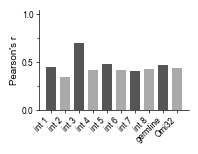

barplot_r_lt_vs_htexpr: {'int 1': '0.444', 'int 2': '0.346', 'int 3': '0.695', 'int 4': '0.417', 'int 5': '0.480', 'int 6': '0.414', 'int 7': '0.411', 'int 8': '0.422', 'germline': '0.471', 'Omi32': '0.439'}


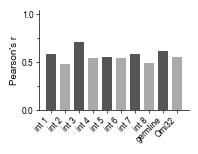

barplot_r_htexpr_vs_pred: {'int 1': '0.582', 'int 2': '0.482', 'int 3': '0.713', 'int 4': '0.542', 'int 5': '0.550', 'int 6': '0.545', 'int 7': '0.586', 'int 8': '0.490', 'germline': '0.616', 'Omi32': '0.555'}


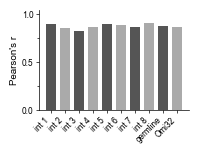

barplot_r_lt_vs_pred: {'int 1': '0.900', 'int 2': '0.853', 'int 3': '0.824', 'int 4': '0.864', 'int 5': '0.902', 'int 6': '0.891', 'int 7': '0.866', 'int 8': '0.913', 'germline': '0.879', 'Omi32': '0.871'}

Displayed 3 barplot figures (not saved).


In [21]:
# Per-reference barplots: Pearson r for all three comparisons 
plt.rcParams.update({
    'font.family': 'Arial', 'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'custom', 'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic', 'mathtext.bf': 'Arial:bold',
})
BAR_COLORS = ['#555555', '#AAAAAA']
CANVAS_W, CANVAS_H = 1.5, 1.0
L, R, T, B = 0.55, 0.1, 0.1, 0.55
fw = L + CANVAS_W + R
fh = T + CANVAS_H + B
bar_comparisons = [
    ('r_LT_vs_Expr',   "Pearson's r", 'barplot_r_lt_vs_htexpr'),
    ('r_Expr_vs_Pred', "Pearson's r", 'barplot_r_htexpr_vs_pred'),
    ('r_LT_vs_Pred',   "Pearson's r", 'barplot_r_lt_vs_pred'),
]

all_abs = per_ab_corr_df['reference_antibody'].tolist()
label_map = {}
num = 1
for ab in all_abs:
    if ab in ('germline', 'Omi32'):
        label_map[ab] = ab
    else:
        label_map[ab] = f'int {num}'
        num += 1
print('Antibody number key:')
for ab, lbl in label_map.items():
    print(f'  {lbl}: {ab}')
print()
print('Antibody number key:')
for ab, lbl in label_map.items():
    print(f'  {lbl}: {ab}')
print()
for r_col, ylabel, fname in bar_comparisons:
    plot_df = per_ab_corr_df[['reference_antibody', r_col]].dropna()
    labels  = [label_map[ab] for ab in plot_df['reference_antibody'].tolist()]
    r_vals  = plot_df[r_col].tolist()
    x       = np.arange(len(labels))
    colors  = [BAR_COLORS[i % 2] for i in range(len(labels))]
    fig = plt.figure(figsize=(fw, fh))
    gs  = GridSpec(1, 1, figure=fig,
                   left=L/fw, right=(L+CANVAS_W)/fw,
                   top=1-T/fh, bottom=B/fh)
    ax = fig.add_subplot(gs[0])
    ax.bar(x, r_vals, color=colors, width=0.7, linewidth=0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6)
    ax.set_ylabel(ylabel, fontsize=7, labelpad=2)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticks([0.25, 0.75], minor=True)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.tick_params(axis='both', which='major', labelsize=6, length=2,
                   width=0.5, direction='out', pad=2)
    ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    plt.show()
    print(f"{fname}: {dict(zip(labels, [f'{r:.3f}' for r in r_vals]))}")
print('\nDisplayed 3 barplot figures (not saved).')


<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:90: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:90: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/375395968.py:76: SyntaxWarning: invalid escape sequence '\m'
  'low-throughput meas,\nΔ log$_{10}$ copy #$_{\mathit{app}}$',
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7707/375395968.py:77: SyntaxWarning: invalid escape sequence '\m'
  'BioPhy-Seq meas,\nΔ log$_{10}$ copy #$_{\mathit{app}}$',
/var/folders/5

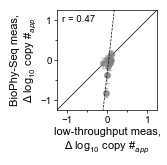

expression_S_Fig_1c: r=0.471, p=2.01e-01, n=9


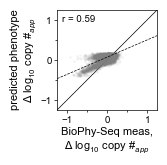

expression_S_Fig_1b: r=0.588, p=0.00e+00, n=8150


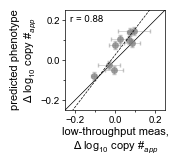

expression_S_Fig_1d: r=0.879, p=1.78e-03, n=9


In [22]:
# delta expression from germline correlation plots: LT vs HT-exp, HT-exp vs Pred, LT vs Pred 

plt.rcParams.update({
    'font.family': 'Arial', 'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'custom', 'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic', 'mathtext.bf': 'Arial:bold',
})
CANVAS_W, CANVAS_H = 1, 1
L, R, T, B = 0.7, 0.2, 0.2, 0.55
fw = L + CANVAS_W + R
fh = T + CANVAS_H + B
HT_SPEC = dict(xlim=(-1.25, 1.25), x_major=[-1, 0, 1], x_minor=[-0.5, 0.5],
               ylim=(-1.25, 1.25), y_major=[-1, 0, 1], y_minor=[-0.5, 0.5])
LT_SPEC = dict(xlim=(-0.25, 0.25), x_major=[-0.2, 0, 0.2], x_minor=[-0.1, 0.1],
               ylim=(-0.25, 0.25), y_major=[-0.2, 0, 0.2], y_minor=[-0.1, 0.1])

# Pull germline delta columns and exclude the self-comparison row (germline itself)
lt_col      = 'mean_delta_ab_GERMLINE'
lt_sem_col  = 'sem_delta_ab_GERMLINE'
expr_col    = 'delta_ab_GERMLINE_expr'
expr_sem_col= 'sem_delta_ab_GERMLINE_expr'
pred_col    = 'delta_ab_GERMLINE_pred'
pred_sem_col= 'sem_delta_ab_GERMLINE_pred'
d_lt_expr = lt_expr_merged[lt_expr_merged['antibody'] != 'GERMLINE'][[lt_col, lt_sem_col, expr_col, expr_sem_col]].dropna()
d_lt_pred = lt_pred_merged[lt_pred_merged['antibody'] != 'GERMLINE'][[lt_col, lt_sem_col, pred_col, pred_sem_col]].dropna()

# HT-experimental vs Predicted: direct geno merge 
if 'expr_expr_full' in globals() and 'expr_pred_full' in globals():
    expr_expr_g = expr_expr_full.copy()
    expr_pred_g = expr_pred_full.copy()
else:
    expr_expr_g = pd.read_csv('../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/expression/filtered_expression_replicates.csv')
    expr_expr_g.rename(columns={'expr_mednorm_mean': 'mean_expr_e', 'expr_mednorm_sem': 'sem_expr_e'}, inplace=True)
    expr_expr_g = expr_expr_g[['geno', 'mean_expr_e', 'sem_expr_e']]
    expr_pred_g = pd.read_csv('../../epistasis_inference/linear_interaction_models/expression/reference-based/predicted_phenotypes/expression_raw_2order_full_biochem_predictions.csv')
    expr_pred_g.rename(columns={'predicted_phenotype': 'mean_expr_p', 'prediction_se': 'sem_expr_p'}, inplace=True)
    expr_pred_g = expr_pred_g[['geno', 'mean_expr_p', 'sem_expr_p']]
expr_expr_g['geno'] = expr_expr_g['geno'].astype(str).str.zfill(13)
expr_pred_g['geno'] = expr_pred_g['geno'].astype(str).str.zfill(13)
d_expr_pred = expr_expr_g[['geno', 'mean_expr_e', 'sem_expr_e']].merge(
    expr_pred_g[['geno', 'mean_expr_p', 'sem_expr_p']],
    on='geno', how='inner'
)
gl_e = d_expr_pred.loc[d_expr_pred['geno'] == '0000000000000', 'mean_expr_e']
gl_p = d_expr_pred.loc[d_expr_pred['geno'] == '0000000000000', 'mean_expr_p']
gl_e_sem = d_expr_pred.loc[d_expr_pred['geno'] == '0000000000000', 'sem_expr_e']
gl_p_sem = d_expr_pred.loc[d_expr_pred['geno'] == '0000000000000', 'sem_expr_p']
if len(gl_e) == 0 or len(gl_p) == 0:
    raise ValueError('GERMLINE genotype (0000000000000) not found in exp/pred expression merge.')
gl_e_val = float(gl_e.iloc[0])
gl_p_val = float(gl_p.iloc[0])
gl_e_sem_val = float(gl_e_sem.iloc[0]) if len(gl_e_sem) > 0 and pd.notna(gl_e_sem.iloc[0]) else np.nan
gl_p_sem_val = float(gl_p_sem.iloc[0]) if len(gl_p_sem) > 0 and pd.notna(gl_p_sem.iloc[0]) else np.nan
d_expr_pred['delta_expr_e'] = d_expr_pred['mean_expr_e'] - gl_e_val
d_expr_pred['delta_expr_p'] = d_expr_pred['mean_expr_p'] - gl_p_val
d_expr_pred['sem_delta_expr_e'] = np.sqrt(
    np.square(d_expr_pred['sem_expr_e'].astype(float)) +
    (gl_e_sem_val ** 2 if np.isfinite(gl_e_sem_val) else np.nan)
)
d_expr_pred['sem_delta_expr_p'] = np.sqrt(
    np.square(d_expr_pred['sem_expr_p'].astype(float)) +
    (gl_p_sem_val ** 2 if np.isfinite(gl_p_sem_val) else np.nan)
)
d_expr_pred = d_expr_pred.dropna(subset=['delta_expr_e', 'delta_expr_p', 'sem_delta_expr_e', 'sem_delta_expr_p'])

# Route expression outputs by Supplemental Figure panel
corr_outdir_map = {
    'expression_S_Fig_1b': S_FIG_1B,
    'expression_S_Fig_1c': S_FIG_1C,
    'expression_S_Fig_1d': S_FIG_1D,
}
comparisons = [
    # HT-exp on x, LT on y
    (d_lt_expr[lt_col].values, d_lt_expr[expr_col].values,
     d_lt_expr[lt_sem_col].values, d_lt_expr[expr_sem_col].values,
     'low-throughput meas,\nΔ log$_{10}$ copy #$_{\mathit{app}}$',
     'BioPhy-Seq meas,\nΔ log$_{10}$ copy #$_{\mathit{app}}$',
     'expression_S_Fig_1c',
     HT_SPEC),
    # HT-exp on x, predicted on y 
    (d_expr_pred['delta_expr_e'].values, d_expr_pred['delta_expr_p'].values,
     d_expr_pred['sem_delta_expr_e'].values, d_expr_pred['sem_delta_expr_p'].values,
     'BioPhy-Seq meas,\nΔ log$_{10}$ copy #$_{\mathit{app}}$',
     'predicted phenotype\nΔ log$_{10}$ copy #$_{\mathit{app}}$',
     'expression_S_Fig_1b',
     HT_SPEC),
    # LT on x, predicted on y
    (d_lt_pred[lt_col].values, d_lt_pred[pred_col].values,
     d_lt_pred[lt_sem_col].values, d_lt_pred[pred_sem_col].values,
     'low-throughput meas,\nΔ log$_{10}$ copy #$_{\mathit{app}}$',
     'predicted phenotype\nΔ log$_{10}$ copy #$_{\mathit{app}}$',
     'expression_S_Fig_1d',
     LT_SPEC),
]
for x, y, xerr, yerr, xlabel, ylabel, fname, ax_spec in comparisons:
    r, p = pearsonr(x, y)
    x0 = np.asarray(x, float)
    y0 = np.asarray(y, float)
    m = np.isfinite(x0) & np.isfinite(y0)
    x0, y0 = x0[m], y0[m]
    def _f(B, x):
        return B[0] * x + B[1]
    model = odr.Model(_f)
    data = odr.RealData(x0, y0)
    out = odr.ODR(data, model, beta0=[1.0, 0.0]).run()
    slope, intercept = out.beta
    fig = plt.figure(figsize=(fw, fh))
    gs = GridSpec(1, 1, figure=fig,
                  left=L/fw, right=(L + CANVAS_W)/fw,
                  top=1 - T/fh, bottom=B/fh)
    ax = fig.add_subplot(gs[0])
    xerr = np.asarray(xerr, float)
    yerr = np.asarray(yerr, float)
    show_errorbars = fname != 'expression_S_Fig_1b'
    if show_errorbars:
        for xi, yi, xe, ye in zip(x, y, xerr, yerr):
            ax.errorbar(
                xi, yi,
                xerr=xe, yerr=ye,
                fmt='none',
                ecolor='gray',
                elinewidth=0.5,
                capsize=1.5,
                alpha=0.45,
                zorder=1
            )
    point_size = 3 if fname == 'expression_S_Fig_1b' else 24
    point_alpha = 0.1 if fname == 'expression_S_Fig_1b' else 0.8
    ax.scatter(x, y, s=point_size, color='gray', alpha=point_alpha, linewidths=0, zorder=2)
    ax.set_xlim(ax_spec['xlim'])
    ax.set_ylim(ax_spec['ylim'])
    ax.set_xticks(ax_spec['x_major'])
    ax.set_yticks(ax_spec['y_major'])
    ax.set_xticks(ax_spec['x_minor'], minor=True)
    ax.set_yticks(ax_spec['y_minor'], minor=True)
    id_min = max(ax_spec['xlim'][0], ax_spec['ylim'][0])
    id_max = min(ax_spec['xlim'][1], ax_spec['ylim'][1])
    ax.plot([id_min, id_max], [id_min, id_max], 'k-', lw=0.5, zorder=0)
    xfit = np.array(ax.get_xlim())
    ax.plot(xfit, slope * xfit + intercept, 'k--', lw=0.5)
    ax.set_xlabel(xlabel, fontsize=8, labelpad=2)
    ax.set_ylabel(ylabel, fontsize=8, labelpad=2)
    ax.text(0.05, 0.95, f'r = {r:.2f}',
            transform=ax.transAxes, fontsize=7, va='top', ha='left')
    ax.tick_params(axis='both', which='major', labelsize=7, length=2,
                   width=0.5, direction='out', pad=2)
    ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    outdir = corr_outdir_map.get(fname, S_FIG_1C)
    fig.savefig(Path(outdir) / (fname + '.pdf'), bbox_inches='tight', transparent=True)
    fig.savefig(Path(outdir) / (fname + '.png'), dpi=2000, bbox_inches='tight', transparent=True)
    plt.show()
    print(f"{fname}: r={r:.3f}, p={p:.2e}, n={len(x0)}")
